# LOBSTER Limit Order Book EDA — AAPL, 2012-06-21 (10 levels)

## What is a Limit Order Book (LOB)?

A limit order book is the ledger an exchange keeps of all resting (unfilled) buy and sell
orders for one stock, sorted by price:

- **Bids** (buy orders) sorted from highest to lowest price — the highest bid is the
  **best bid**, the price a buyer is currently willing to pay.
- **Asks / offers** (sell orders) sorted from lowest to highest price — the lowest ask is
  the **best ask**, the price a seller is currently willing to accept.
- The gap between best bid and best ask is the **spread**; their average is the
  **mid-price**, the standard reference price for the stock at that instant.

Every new order, cancellation, or trade changes this book. LOBSTER reconstructs the full
book from raw NASDAQ TotalView-ITCH messages, giving us, for every single event, both
**what happened** (the message) and **the resulting state of the book** (the snapshot).

## The dataset

This sample covers **AAPL on 2012-06-21**, the **full regular trading session**
(09:30:00–16:00:00 ET, timestamps in seconds after midnight), reconstructed to
**10 price levels** on each side. Two files, row-aligned 1:1 (row *i* of the orderbook
file is the book state immediately *after* row *i* of the message file is applied):

**Message file** — one row per event:

| col | name | meaning |
|---|---|---|
| 1 | `time` | seconds after midnight, nanosecond precision |
| 2 | `event_type` | 1=New limit order, 2=Partial cancel, 3=Full delete, 4=Visible execution, 5=Hidden execution, 7=Trading halt |
| 3 | `order_id` | unique resting-order identifier |
| 4 | `size` | number of shares |
| 5 | `price` | in **fixed point**, price × 10,000 |
| 6 | `direction` | -1 = sell-side order / sell-initiated trade, 1 = buy-side order / buy-initiated trade |

**Orderbook file** — one row per event, book state after that event:

`ask_price_1, ask_size_1, bid_price_1, bid_size_1, ask_price_2, ask_size_2, ...` up to
level 10. Prices are fixed-point (× 10,000) exactly like the message file.

> Note: execution direction is recorded from the perspective of the **resting (limit)
> order being hit**, not the aggressor. `direction = -1` on an execution means a sell
> limit order was hit, i.e. the trade was **buyer-initiated**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

DATA_DIR = "LOBSTER_SampleFile_AAPL_2012-06-21_10"
MSG_FILE = f"{DATA_DIR}/AAPL_2012-06-21_34200000_57600000_message_10.csv"
OB_FILE = f"{DATA_DIR}/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"
N_LEVELS = 10
TICK = 0.01  # NASDAQ minimum tick size for stocks > $1

EVENT_TYPE_LABELS = {
    1: "New limit order",
    2: "Partial cancel",
    3: "Full delete",
    4: "Execution (visible)",
    5: "Execution (hidden)",
    7: "Trading halt",
}


## 1. Load the data

Neither file ships column headers, so we supply them explicitly and immediately rescale
prices from LOBSTER's fixed-point integers (× 10,000) to dollars. We also convert `time`
(seconds after midnight) into a proper time-of-day for readable axes.

In [2]:
msg_cols = ["time", "event_type", "order_id", "size", "price", "direction"]

ob_cols = []
for lvl in range(1, N_LEVELS + 1):
    ob_cols += [f"ask_price_{lvl}", f"ask_size_{lvl}", f"bid_price_{lvl}", f"bid_size_{lvl}"]

df_msg = pd.read_csv(MSG_FILE, names=msg_cols)
df_ob = pd.read_csv(OB_FILE, names=ob_cols)

assert len(df_msg) == len(df_ob), "message and orderbook files must be row-aligned"

# Rescale fixed-point prices (x10,000) to dollars
df_msg["price"] = df_msg["price"] / 10_000
price_cols = [c for c in df_ob.columns if "price" in c]
df_ob[price_cols] = df_ob[price_cols] / 10_000

# Human-readable time-of-day, still keeping the original float seconds for arithmetic
df_msg["time_sec"] = df_msg["time"]
df_msg["time"] = pd.to_datetime(df_msg["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))
df_msg["event_label"] = df_msg["event_type"].map(EVENT_TYPE_LABELS)

# One combined frame: each row = an event + the resulting book state
df = pd.concat([df_msg, df_ob], axis=1)

print(f"{len(df):,} events from {df_msg['time'].min().time()} to {df_msg['time'].max().time()}")
df.head(20)

400,391 events from 09:30:00.004241 to 15:59:59.913117


,time,event_type,order_id,size,price,direction,time_sec,event_label,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,bid_price_3,bid_size_3,ask_price_4,ask_size_4,bid_price_4,bid_size_4,ask_price_5,ask_size_5,bid_price_5,bid_size_5,ask_price_6,ask_size_6,bid_price_6,bid_size_6,ask_price_7,ask_size_7,bid_price_7,bid_size_7,ask_price_8,ask_size_8,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
0,2012-06-21 09:30:00.004241228,1,16113575,18,585.33,1,34200.004241,New limit order,585.94,200,585.33,18,585.98,200,585.30,150,586.10,200,585.10,5,586.89,300,585.01,89,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300,587.65,1160,584.38,200,587.90,500,584.27,300
1,2012-06-21 09:30:00.004260540,1,16113584,18,585.32,1,34200.004261,New limit order,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,585.30,150,586.89,300,585.10,5,586.95,50,585.01,89,587.00,100,584.97,5,587.10,10,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300,587.90,500,584.38,200
2,2012-06-21 09:30:00.004447460,1,16113594,18,585.31,1,34200.004447,New limit order,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,585.31,18,586.89,300,585.30,150,586.95,50,585.10,5,587.00,100,585.01,89,587.10,10,584.97,5,587.39,100,584.93,300,587.65,1160,584.65,300,587.90,500,584.53,300
3,2012-06-21 09:30:00.025551796,1,16120456,18,585.91,-1,34200.025552,New limit order,585.91,18,585.33,18,585.94,200,585.32,18,585.98,200,585.31,18,586.10,200,585.30,150,586.89,300,585.10,5,586.95,50,585.01,89,587.00,100,584.97,5,587.10,10,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300
4,2012-06-21 09:30:00.025579453,1,16120480,18,585.92,-1,34200.025580,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.94,200,585.31,18,585.98,200,585.30,150,586.10,200,585.10,5,586.89,300,585.01,89,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300
5,2012-06-21 09:30:00.025613070,1,16120503,18,585.93,-1,34200.025613,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.93,18,585.31,18,585.94,200,585.30,150,585.98,200,585.10,5,586.10,200,585.01,89,586.89,300,584.97,5,586.95,50,584.93,300,587.00,100,584.65,300,587.10,10,584.53,300
6,2012-06-21 09:30:00.050240993,1,16127688,100,585.00,1,34200.050241,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.93,18,585.31,18,585.94,200,585.30,150,585.98,200,585.10,5,586.10,200,585.01,89,586.89,300,585.00,100,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300
7,2012-06-21 09:30:00.201518059,1,16166035,100,585.93,-1,34200.201518,New limit order,585.91,18,585.33,18,585.92,18,585.32,18,585.93,118,585.31,18,585.94,200,585.30,150,585.98,200,585.10,5,586.10,200,585.01,89,586.89,300,585.00,100,586.95,50,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300
8,2012-06-21 09:30:00.201735973,3,16113594,18,585.31,1,34200.201736,Full delete,585.91,18,585.33,18,585.92,18,585.32,18,585.93,118,585.30,150,585.94,200,585.10,5,585.98,200,585.01,89,586.10,200,585.00,100,586.89,300,584.97,5,586.95,50,584.93,300,587.00,100,584.65,300,587.10,10,584.53,300
9,2012-06-21 09:30:00.201742411,3,16113584,18,585.32,1,34200.201742,Full delete,585.91,18,585.33,18,585.92,18,585.30,150,585.93,118,585.10,5,585.94,200,585.01,89,585.98,200,585.00,100,586.10,200,584.97,5,586.89,300,584.93,300,586.95,50,584.65,300,587.00,100,584.53,300,587.10,10,584.38,200


## 2. Sanity checks

Confirm shapes, dtypes, and that there's no missing data before trusting any downstream
statistic.

In [3]:
print("Shapes:", df_msg.shape, df_ob.shape)
print("\nMissing values (msg):", df_msg.isna().sum().sum(), " | (orderbook):", df_ob.isna().sum().sum())
print("\nUnique order IDs:", df_msg["order_id"].nunique(), "/ events:", len(df_msg))
print("Trading halts (type 7):", (df_msg["event_type"] == 7).sum())

# The book should always be internally consistent: best ask > best bid at every event
crossed = (df_ob["ask_price_1"] <= df_ob["bid_price_1"]).sum()
print("Crossed-book events (ask_1 <= bid_1):", crossed)

df_msg[["time_sec", "size", "price"]].describe()

Shapes: (400391, 8) (400391, 40)

Missing values (msg): 0  | (orderbook): 0

Unique order IDs: 198668 / events: 400391
Trading halts (type 7): 0
Crossed-book events (ask_1 <= bid_1): 0


,time_sec,size,price
count,400391.000000,400391.000000,400391.000000
mean,46281.368129,88.740891,583.170209
std,7490.018003,94.838261,2.837093
min,34200.004241,1.000000,577.350000
25%,39551.398939,24.000000,581.240000
50%,45969.414798,100.000000,583.290000
75%,53517.590507,100.000000,585.660000
max,57599.913118,15000.000000,588.320000


## 3. Event type & order-flow composition

What kind of activity fills the book? Most events are order placements and cancellations
— actual trades (executions) are a minority. This ratio is a basic signature of
electronic markets: liquidity providers post and pull orders far more often than trades
actually happen.

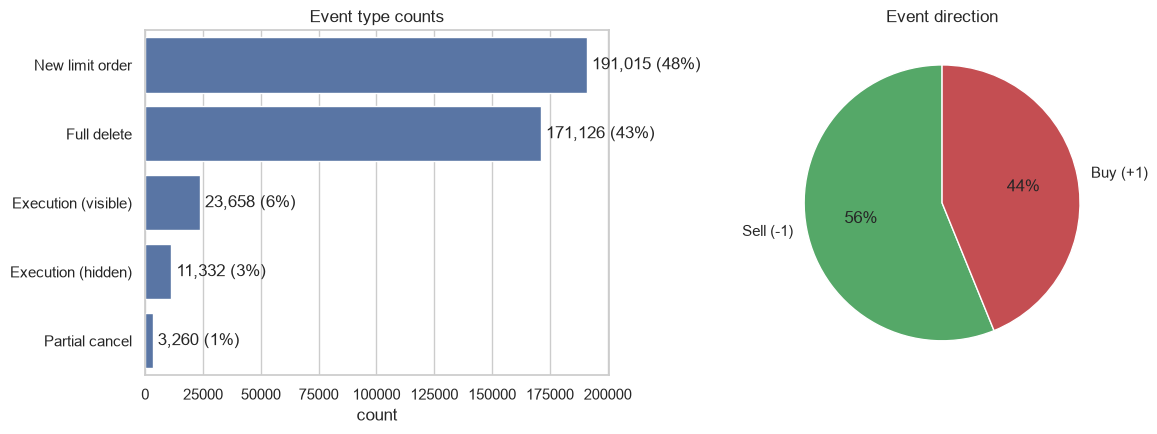

Executions are 8.7% of all events (23,658 visible + 11,332 hidden)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

event_counts = df_msg["event_label"].value_counts()
sns.barplot(x=event_counts.values, y=event_counts.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Event type counts")
axes[0].set_xlabel("count")
axes[0].set_ylabel("")
for i, v in enumerate(event_counts.values):
    axes[0].text(v, i, f" {v:,} ({v/len(df_msg):.0%})", va="center")

direction_counts = df_msg["direction"].map({1: "Buy (+1)", -1: "Sell (-1)"}).value_counts()
axes[1].pie(direction_counts.values, labels=direction_counts.index, autopct="%1.0f%%",
            colors=["#55A868", "#C44E52"], startangle=90)
axes[1].set_title("Event direction")

plt.tight_layout()
plt.show()

trades = df_msg[df_msg["event_type"].isin([4, 5])]
print(f"Executions are {len(trades)/len(df_msg):.1%} of all events "
      f"({(df_msg['event_type']==4).sum():,} visible + {(df_msg['event_type']==5).sum():,} hidden)")

## 4. Intraday activity pattern

Bucket events into 1-minute bins across the session. Equity markets famously trade in a
**U-shape**: heavy activity right at the open and into the close, quieter through the
midday lull.

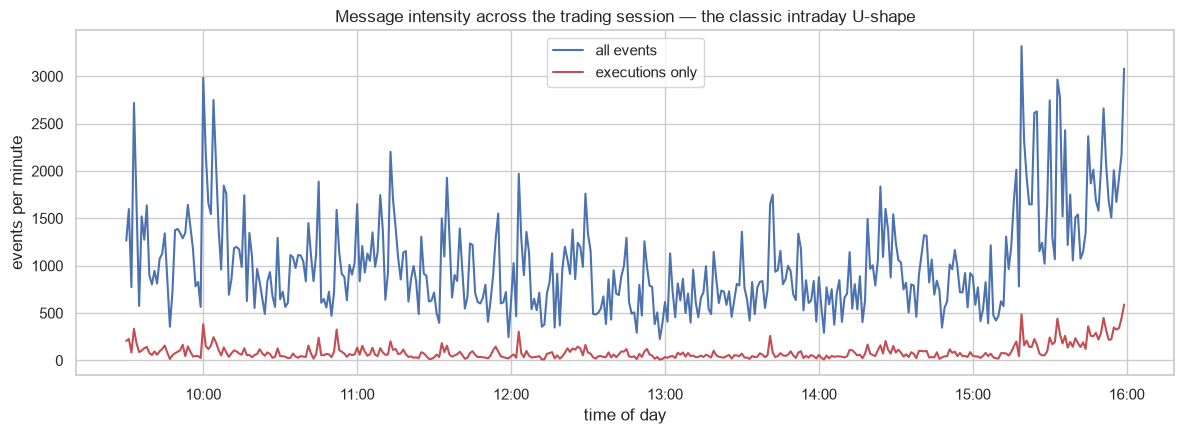

In [5]:
events_per_min = df_msg.set_index("time").resample("1min").size()
trades_per_min = trades.set_index("time").resample("1min").size()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(events_per_min.index, events_per_min.values, label="all events", color="#4C72B0")
ax.plot(trades_per_min.index, trades_per_min.values, label="executions only", color="#C44E52")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time of day")
ax.set_ylabel("events per minute")
ax.set_title("Message intensity across the trading session — the classic intraday U-shape")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Event inter-arrival times

The time gap between consecutive events. In real markets this is **not** exponential /
memoryless — activity clusters in bursts (algorithms firing in quick sequences), so we
expect a heavy right tail even on a log scale, and a spike near zero from same-timestamp
or sub-millisecond bursts.

count    400390.000000
mean         58.442790
std         208.833216
min           0.000000
25%           0.073261
50%           0.638858
75%           9.319839
max        8155.205382
Name: time_sec, dtype: float64

Median gap: 0.639 ms | 99th pct: 997.8 ms


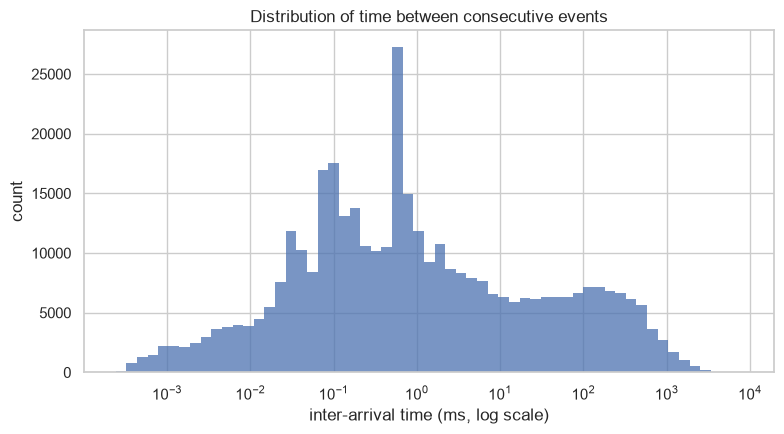

In [6]:
inter_arrival = df_msg["time_sec"].diff().dropna()
inter_arrival_ms = inter_arrival * 1000

print(inter_arrival_ms.describe())
print(f"\nMedian gap: {inter_arrival_ms.median():.3f} ms | 99th pct: {inter_arrival_ms.quantile(0.99):.1f} ms")

fig, ax = plt.subplots(figsize=(8, 4.5))
positive = inter_arrival_ms[inter_arrival_ms > 0]
sns.histplot(positive, bins=np.logspace(np.log10(positive.min()), np.log10(positive.max()), 60),
             ax=ax, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("inter-arrival time (ms, log scale)")
ax.set_ylabel("count")
ax.set_title("Distribution of time between consecutive events")
plt.tight_layout()
plt.show()

## 6. Mid-price and spread

Two of the most fundamental derived series in market microstructure:

- **mid-price** = (best bid + best ask) / 2 — the reference "fair value" proxy
- **spread** = best ask − best bid — the cost of demanding immediacy; compensation
  liquidity providers earn for standing ready to trade

We also express spread **in ticks** (spread ÷ $0.01), since on NASDAQ the spread is
constrained to be a whole number of ticks.

count    400391.000000
mean        583.152849
std           2.834982
min         577.480000
25%         581.245000
50%         583.235000
75%         585.660000
max         588.185000
Name: mid_price, dtype: float64

count    400391.000000
mean         15.348894
std           7.415759
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          92.000000
Name: spread_ticks, dtype: float64


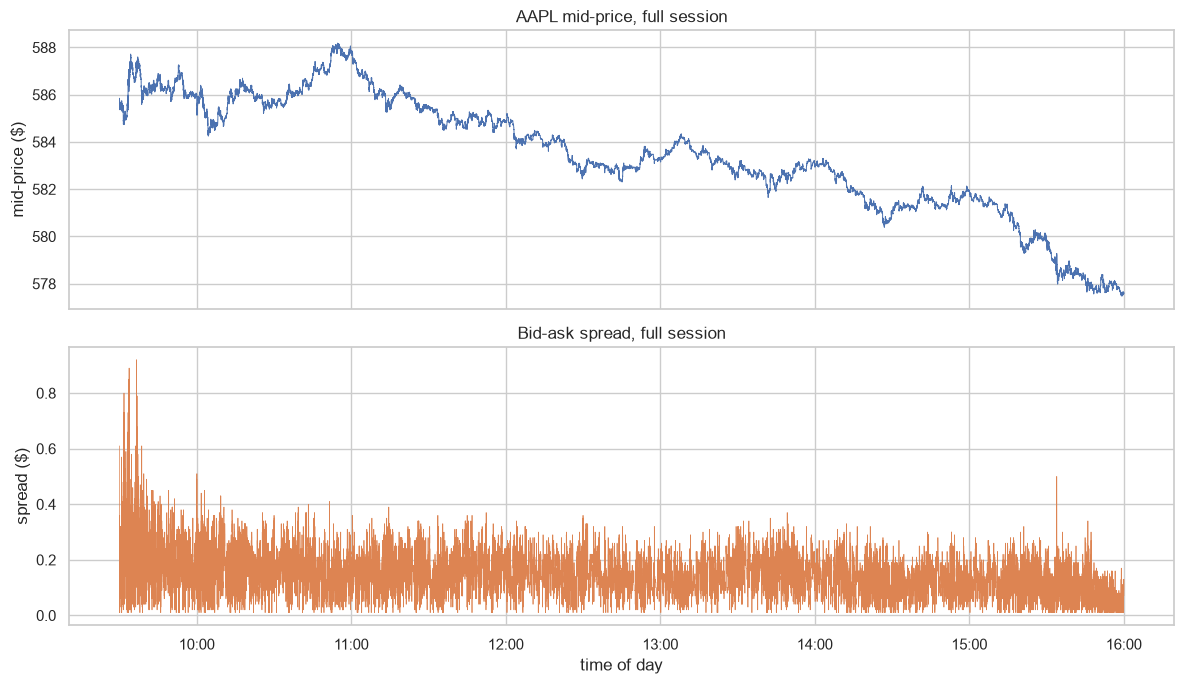

In [7]:
df["mid_price"] = (df["ask_price_1"] + df["bid_price_1"]) / 2
df["spread"] = df["ask_price_1"] - df["bid_price_1"]
df["spread_ticks"] = (df["spread"] / TICK).round().astype(int)

print(df["mid_price"].describe())
print()
print(df["spread_ticks"].describe())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(df["time"], df["mid_price"], color="#4C72B0", linewidth=0.7)
axes[0].set_ylabel("mid-price ($)")
axes[0].set_title("AAPL mid-price, full session")

axes[1].plot(df["time"], df["spread"], color="#DD8452", linewidth=0.5)
axes[1].set_ylabel("spread ($)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_title("Bid-ask spread, full session")

plt.tight_layout()
plt.show()

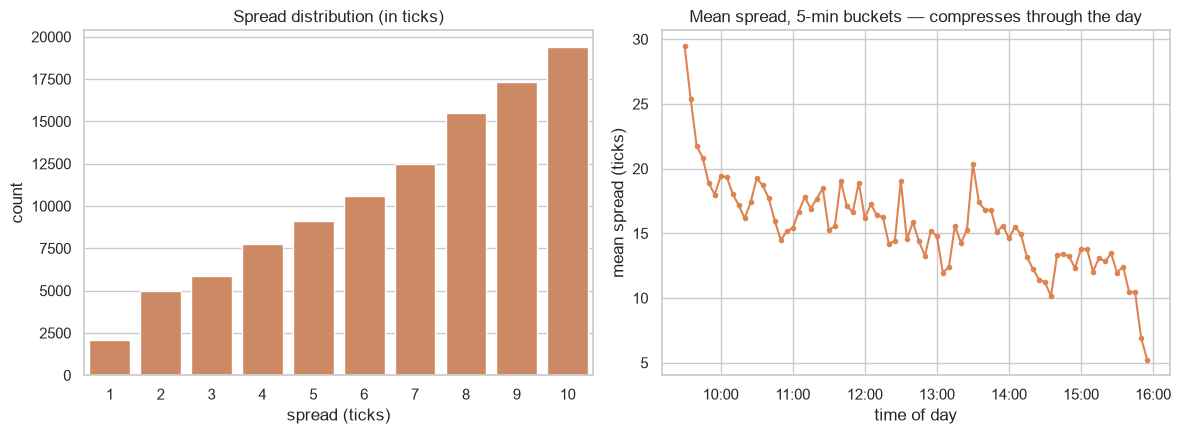

1-tick (minimum) spread holds 0.5% of the time


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

spread_counts = df["spread_ticks"].value_counts().sort_index().head(10)
sns.barplot(x=spread_counts.index, y=spread_counts.values, ax=axes[0], color="#DD8452")
axes[0].set_xlabel("spread (ticks)")
axes[0].set_ylabel("count")
axes[0].set_title("Spread distribution (in ticks)")

spread_by_min = df.set_index("time")["spread_ticks"].resample("5min").mean()
axes[1].plot(spread_by_min.index, spread_by_min.values, color="#DD8452", marker="o", markersize=3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("mean spread (ticks)")
axes[1].set_title("Mean spread, 5-min buckets — compresses through the day")

plt.tight_layout()
plt.show()

print(f"1-tick (minimum) spread holds {(df['spread_ticks']==1).mean():.1%} of the time")

## 7. Order book shape

Average resting size at each of the 10 levels, and a snapshot of the actual book at one
instant. Size typically grows away from the best price — the top of book is thin (it
absorbs the most competition) while deeper levels accumulate more resting size.

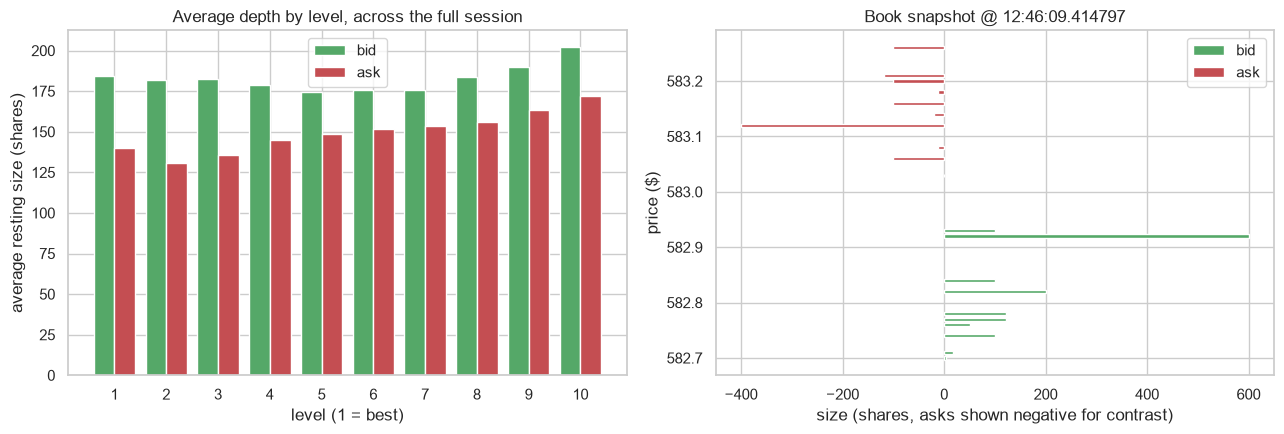

In [9]:
avg_bid_size = [df_ob[f"bid_size_{lvl}"].mean() for lvl in range(1, N_LEVELS + 1)]
avg_ask_size = [df_ob[f"ask_size_{lvl}"].mean() for lvl in range(1, N_LEVELS + 1)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

levels = np.arange(1, N_LEVELS + 1)
width = 0.4
axes[0].bar(levels - width/2, avg_bid_size, width, label="bid", color="#55A868")
axes[0].bar(levels + width/2, avg_ask_size, width, label="ask", color="#C44E52")
axes[0].set_xlabel("level (1 = best)")
axes[0].set_ylabel("average resting size (shares)")
axes[0].set_title("Average depth by level, across the full session")
axes[0].set_xticks(levels)
axes[0].legend()

# Snapshot: the actual book at a single instant (midday)
snap_idx = df.index[len(df) // 2]
snap = df.loc[snap_idx]
bid_prices = [snap[f"bid_price_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
bid_sizes = [snap[f"bid_size_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
ask_prices = [snap[f"ask_price_{lvl}"] for lvl in range(1, N_LEVELS + 1)]
ask_sizes = [snap[f"ask_size_{lvl}"] for lvl in range(1, N_LEVELS + 1)]

axes[1].barh(bid_prices, bid_sizes, height=0.006, color="#55A868", label="bid")
axes[1].barh(ask_prices, [-s for s in ask_sizes], height=0.006, color="#C44E52", label="ask")
axes[1].set_xlabel("size (shares, asks shown negative for contrast)")
axes[1].set_ylabel("price ($)")
axes[1].set_title(f"Book snapshot @ {snap['time'].time()}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Order book imbalance vs. future price moves

**Order book imbalance (OBI)** at the top of book:

$$\text{OBI} = \frac{\text{bid\_size}_1 - \text{ask\_size}_1}{\text{bid\_size}_1 + \text{ask\_size}_1} \in [-1, 1]$$

Positive OBI means more resting buy interest than sell interest at the best prices — a
textbook short-horizon signal that price should tick **up** next (more buyers waiting =
sellers get lifted first), and vice versa. We check this by binning OBI at each event and
looking at the mid-price change over the next 50 events.

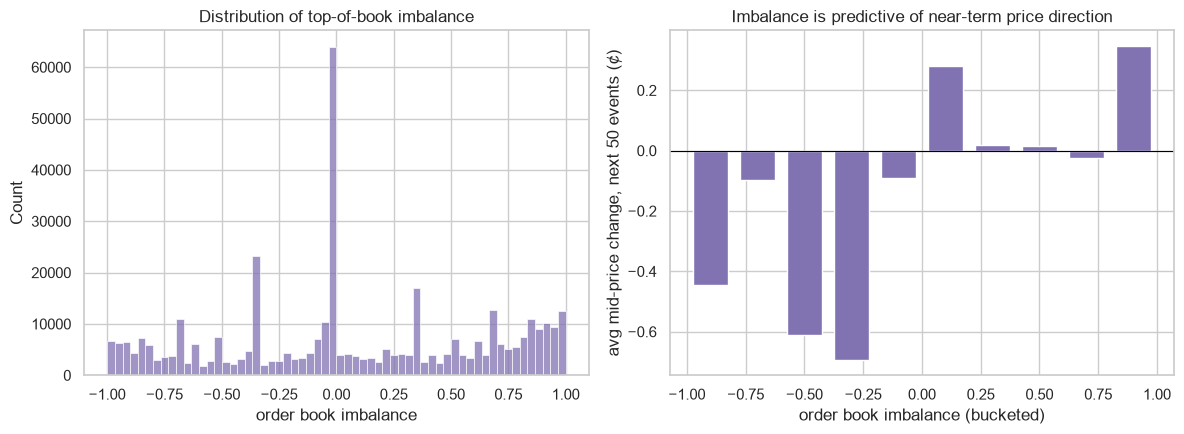

Correlation(OBI, future mid-price change): 0.0442


In [10]:
df["obi"] = (df["bid_size_1"] - df["ask_size_1"]) / (df["bid_size_1"] + df["ask_size_1"])

HORIZON = 50  # events ahead
df["future_mid_change"] = df["mid_price"].shift(-HORIZON) - df["mid_price"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["obi"], bins=60, ax=axes[0], color="#8172B2")
axes[0].set_xlabel("order book imbalance")
axes[0].set_title("Distribution of top-of-book imbalance")

valid = df.dropna(subset=["future_mid_change"]).copy()
valid["obi_bin"] = pd.cut(valid["obi"], bins=np.linspace(-1, 1, 11))
binned = valid.groupby("obi_bin", observed=True)["future_mid_change"].mean() * 100  # in cents
bin_centers = [interval.mid for interval in binned.index]

axes[1].bar(bin_centers, binned.values, width=0.15, color="#8172B2")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("order book imbalance (bucketed)")
axes[1].set_ylabel(f"avg mid-price change, next {HORIZON} events (¢)")
axes[1].set_title("Imbalance is predictive of near-term price direction")

plt.tight_layout()
plt.show()

print("Correlation(OBI, future mid-price change):", valid["obi"].corr(valid["future_mid_change"]).round(4))

## 9. Trades: size, sign, and volume profile

Filtering to executions only (`event_type` 4 or 5). Recall `direction = -1` on an
execution means a **resting sell** order was hit → the trade was **buyer-initiated**;
`direction = 1` means seller-initiated.

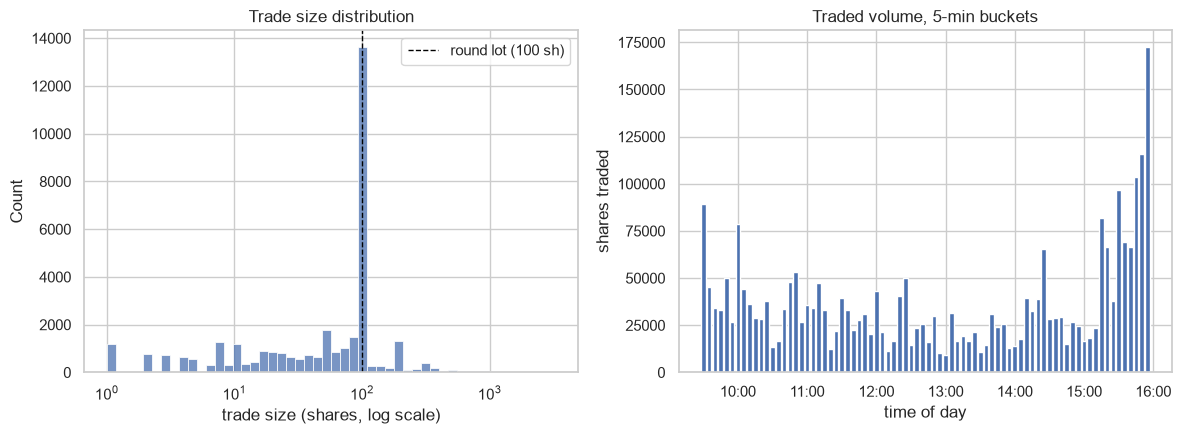

                  count      sum       mean
initiator                                  
buyer-initiated   16729  1314336  78.566322
seller-initiated  18261  1535804  84.102952

% of executed volume that is buyer-initiated: 46.1%


In [11]:
trades = trades.copy()
trades["initiator"] = trades["direction"].map({-1: "buyer-initiated", 1: "seller-initiated"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(trades["size"], bins=50, log_scale=(True, False), ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("trade size (shares, log scale)")
axes[0].set_title("Trade size distribution")
axes[0].axvline(100, color="black", linestyle="--", linewidth=1, label="round lot (100 sh)")
axes[0].legend()

volume_by_min = trades.set_index("time").groupby(pd.Grouper(freq="5min"))["size"].sum()
axes[1].bar(volume_by_min.index, volume_by_min.values, width=0.0028, color="#4C72B0")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("shares traded")
axes[1].set_title("Traded volume, 5-min buckets")

plt.tight_layout()
plt.show()

print(trades.groupby("initiator")["size"].agg(["count", "sum", "mean"]))
print(f"\n% of executed volume that is buyer-initiated: "
      f"{trades.loc[trades['initiator']=='buyer-initiated','size'].sum() / trades['size'].sum():.1%}")

## 10. New limit order sizes

Order sizes tend to cluster on **round lots** (multiples of 100 shares) — a well-known
artifact of how both human traders and execution algorithms slice orders.

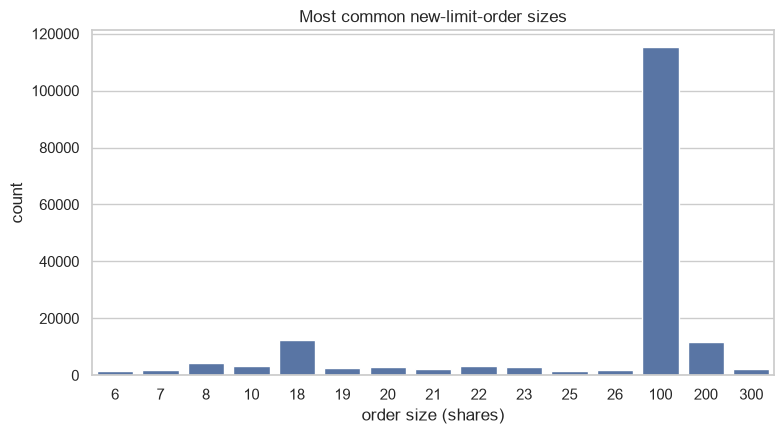

Share of new orders that are an exact multiple of 100 shares: 68.6%


In [12]:
new_orders = df_msg[df_msg["event_type"] == 1]

fig, ax = plt.subplots(figsize=(8, 4.5))
top_sizes = new_orders["size"].value_counts().head(15).sort_index()
sns.barplot(x=top_sizes.index.astype(str), y=top_sizes.values, ax=ax, color="#4C72B0")
ax.set_xlabel("order size (shares)")
ax.set_ylabel("count")
ax.set_title("Most common new-limit-order sizes")
plt.tight_layout()
plt.show()

round_lot_share = (new_orders["size"] % 100 == 0).mean()
print(f"Share of new orders that are an exact multiple of 100 shares: {round_lot_share:.1%}")

## Summary

- ~400k events over one session; **new orders (48%)** and **full deletes (43%)** dominate,
  executions are under 9% — the book churns far more than it trades.
- Message intensity and traded volume both show the classic **intraday U-shape**: busy
  at the open, quiet at midday, busiest of all into the close.
- Event inter-arrival times are **heavy-tailed / bursty**, not memoryless — consistent
  with clustered, algorithmic order flow rather than a simple Poisson process.
- The spread is **not** pinned at the 1-tick minimum here — that only happens 0.5% of
  the time. Instead it **compresses steadily through the day**, from a wide ~26 ticks
  (~$0.26) right after the open down to ~7 ticks by the close, with a session median
  around 15 ticks (~$0.15) on a ~$583 stock.
- Book depth **grows away from the touch** — level 1 is thin, deeper levels hold more
  resting size.
- **Order book imbalance predicts short-horizon price direction**: buy-heavy books tend
  to tick up next, sell-heavy books tick down — the correlation is modest but
  directionally consistent, which is exactly the kind of signal high-frequency market
  making strategies exploit.
- Order sizes cluster heavily on **round lots** (69% of new orders are exact multiples
  of 100 shares); buyer- and seller-initiated trade volume are roughly balanced (46%/54%).

### Natural next steps
- Extend this pipeline to the 1/5/30/50-level files or other tickers (AMZN, GOOG, INTC,
  MSFT, SPY) to compare liquidity profiles across names.
- Build a feature set (OBI at multiple levels, queue position, realized volatility,
  trade-flow imbalance) for a short-horizon price-direction model.
- Model the event stream itself with a **Hawkes process** to capture the self-exciting
  clustering seen in the inter-arrival plot.

# Part 2 — TWAP execution simulation

**TWAP (Time-Weighted Average Price)** execution splits a large "parent" order into
equal-sized "child" slices spaced evenly across a time window, on the theory that
trading steadily over time — rather than all at once — reduces market impact and
avoids betting on *when* during the window the price is best.

We simulate a **10,000-share buy** (≈0.35% of the day's ~2.85M-share volume — small
enough that a no-market-impact assumption is reasonable) split into 20 equal-time
slices across the full session. Each slice is filled as an **aggressive marketable
order that walks the book**: it takes level 1, then level 2, etc., against the
*actual historical order book* at that moment, until the slice is fully filled. This
is a conservative baseline — real execution algorithms often post passively and can
do better — but it gives a clean worst-case cost estimate purely from the book's
displayed liquidity.

Two caveats worth being explicit about:
- **No feedback loop**: our hypothetical fills consume liquidity from the snapshot
  for cost purposes but don't alter the historical book that later events see. This
  is the standard simplification for backtesting execution against historical LOB
  data.
- **Two different benchmarks** answer two different questions:
  - **Implementation Shortfall** (vs. the arrival mid-price at 09:30:00) captures
    *total* cost — spread/impact **plus** whatever the market did over the day.
  - **TWAP benchmark** (the size-weighted average of the mid-price observed at each
    slice) isolates *execution quality* — did we cross the spread and walk the book
    more expensively than the prevailing price at the time, independent of the
    day's overall drift?

The code below is a corrected version of the original draft: share counts are now
integers that sum exactly to the target (the draft used `total_shares / n_trades`,
which only sums exactly when it happens to divide evenly), snapshot lookups are
bounds-checked so a schedule time at or past the last event can't crash with an
`IndexError`, and each trade's contemporaneous mid-price and per-slice slippage are
recorded for the benchmark and plots below.

In [18]:
def simulate_scheduled_execution(df_msg, df_ob, target_times, total_shares, arrival_sec=None, label="Execution"):
    """
    범용 스케줄 기반 매수 실행 엔진.

    target_times의 각 시각마다 total_shares를 균등 분할한 슬라이스 하나를, 그 시점의
    과거 오더북 스냅샷에서 호가창을 잠식(walk the book)하는 시장가로 체결한다고 가정한다.
    naive single-shot(스케줄 1개), TWAP(균등 시간 스케줄), VWAP(거래량 클록 스케줄)은
    모두 이 함수에 서로 다른 target_times를 넘기는 특수 케이스일 뿐이다.

    arrival_sec(모(母)주문이 발생한 진짜 의사결정 시점)은 스케줄의 첫 체결 시각과 별개다.
    TWAP/naive는 둘이 같지만(첫 슬라이스가 곧 09:30:00), VWAP은 첫 거래량-클록 슬라이스가
    한참 뒤에 발생할 수 있으므로 반드시 분리해서 계산해야 Implementation Shortfall이
    스케줄 간에 공정하게 비교된다. 지정하지 않으면 target_times[0]을 그대로 사용한다.

    :param df_msg: LOBSTER 메시지 DataFrame (time_sec 컬럼 포함)
    :param df_ob: LOBSTER 오더북 DataFrame (달러 단위 가격)
    :param target_times: 각 슬라이스를 체결할 목표 시각(초) 리스트/배열
    :param total_shares: 총 매수 목표 수량
    :param arrival_sec: 모주문의 의사결정 시각(초). None이면 target_times[0] 사용
    :param label: 출력용 라벨
    :return: (summary dict, trades DataFrame)
    """
    n_trades = len(target_times)
    n_levels = sum(1 for c in df_ob.columns if c.startswith("ask_price_"))
    time_arr = df_msg["time_sec"].values
    last_idx = len(df_ob) - 1

    # 정수 수량 스케줄: 나머지는 앞쪽 슬라이스에 1주씩 배분해 합계가 정확히 total_shares가 되도록 함
    base_size, remainder = divmod(total_shares, n_trades)
    slice_sizes = [base_size + 1 if i < remainder else base_size for i in range(n_trades)]

    if arrival_sec is None:
        arrival_sec = target_times[0]
    idx_start = min(np.searchsorted(time_arr, arrival_sec), last_idx)
    arrival_price = (df_ob.iloc[idx_start]["ask_price_1"] + df_ob.iloc[idx_start]["bid_price_1"]) / 2.0

    records = []
    total_cost = 0.0

    for i, (t, size) in enumerate(zip(target_times, slice_sizes)):
        if size == 0:
            continue
        idx = min(np.searchsorted(time_arr, t), last_idx)
        ob_state = df_ob.iloc[idx]
        mid_price = (ob_state["ask_price_1"] + ob_state["bid_price_1"]) / 2.0

        shares_remaining = size
        cost = 0.0
        lvl = 1
        while shares_remaining > 0 and lvl <= n_levels:
            ask_price = ob_state[f"ask_price_{lvl}"]
            ask_size = ob_state[f"ask_size_{lvl}"]
            fill = min(shares_remaining, ask_size)
            cost += fill * ask_price
            shares_remaining -= fill
            if shares_remaining > 0:
                lvl += 1

        levels_walked = min(lvl, n_levels)
        if shares_remaining > 0:
            print(f"[{label}] Warning: depth exhausted to level {n_levels} at t={t:.1f}s "
                  f"({shares_remaining} sh short) — filling remainder at level-{n_levels} price")
            cost += shares_remaining * ob_state[f"ask_price_{n_levels}"]
            shares_remaining = 0

        avg_price = cost / size
        total_cost += cost
        records.append({
            "trade_num": i + 1,
            "time_sec": t,
            "shares": size,
            "avg_fill_price": avg_price,
            "contemporaneous_mid": mid_price,
            "slippage_vs_mid_bps": (avg_price - mid_price) / mid_price * 10_000,
            "levels_walked": levels_walked,
        })

    trades_df = pd.DataFrame(records)

    avg_execution_price = total_cost / total_shares
    is_dollars = avg_execution_price - arrival_price
    is_bps = is_dollars / arrival_price * 10_000

    # size-가중 평균 contemporaneous mid = 이 스케줄 자체의 "벤치마크 가격"
    benchmark_price = np.average(trades_df["contemporaneous_mid"], weights=trades_df["shares"])
    vs_benchmark_dollars = avg_execution_price - benchmark_price
    vs_benchmark_bps = vs_benchmark_dollars / benchmark_price * 10_000

    summary = {
        "label": label,
        "total_shares": total_shares,
        "n_trades": n_trades,
        "arrival_price": arrival_price,
        "benchmark_price": benchmark_price,
        "avg_execution_price": avg_execution_price,
        "IS_dollars": is_dollars,
        "IS_bps": is_bps,
        "vs_benchmark_dollars": vs_benchmark_dollars,
        "vs_benchmark_bps": vs_benchmark_bps,
        "avg_levels_walked": trades_df["levels_walked"].mean(),
    }

    print(f"--- {label}: Execution Summary ---")
    print(f"Total shares          : {total_shares:,} in {n_trades} slice(s)")
    print(f"Arrival mid-price     : ${arrival_price:.4f}")
    print(f"Benchmark price       : ${benchmark_price:.4f}  (size-wtd avg mid at each slice)")
    print(f"Avg execution price   : ${avg_execution_price:.4f}")
    print(f"Avg levels walked     : {summary['avg_levels_walked']:.1f} / {n_levels}")
    print(f"Implementation Shortfall vs arrival : {is_dollars:+.4f} ({is_bps:+.2f} bps)")
    print(f"Slippage vs benchmark                : {vs_benchmark_dollars:+.4f} ({vs_benchmark_bps:+.2f} bps)\n")

    return summary, trades_df


def simulate_twap_buy(df_msg, df_ob, total_shares=10_000, n_trades=20, start_sec=34_200, end_sec=57_600):
    """TWAP: n_trades개 슬라이스를 실행 구간에 걸쳐 균등한 시간 간격으로 배치."""
    target_times = np.linspace(start_sec, end_sec - 1, n_trades)
    return simulate_scheduled_execution(df_msg, df_ob, target_times, total_shares,
                                         arrival_sec=start_sec, label="TWAP (time-clock)")


summary, trades_df = simulate_twap_buy(df_msg, df_ob, total_shares=10_000, n_trades=20)
trades_df

--- TWAP (time-clock): Execution Summary ---
Total shares          : 10,000 in 20 slice(s)
Arrival mid-price     : $585.6350
Benchmark price       : $583.4098  (size-wtd avg mid at each slice)
Avg execution price   : $583.5521
Avg levels walked     : 4.9 / 10
Implementation Shortfall vs arrival : -2.0829 (-35.57 bps)
Slippage vs benchmark                : +0.1423 (+2.44 bps)



,trade_num,time_sec,shares,avg_fill_price,contemporaneous_mid,slippage_vs_mid_bps,levels_walked
0,1,34200.000000,500,585.98800,585.635,6.027645,3
1,2,35431.526316,500,586.14518,586.005,2.392130,4
2,3,36663.052632,500,585.11950,585.000,2.042735,4
3,4,37894.578947,500,585.94848,585.790,2.705406,6
4,5,39126.105263,500,587.57594,587.515,1.037250,2
5,6,40357.631579,500,586.24860,586.090,2.706069,5
6,7,41589.157895,500,585.43208,585.345,1.487670,4
7,8,42820.684211,500,585.33684,585.185,2.594735,3
8,9,44052.210526,500,584.20612,584.085,2.073671,9
9,10,45283.736842,500,583.28970,583.045,4.196932,9


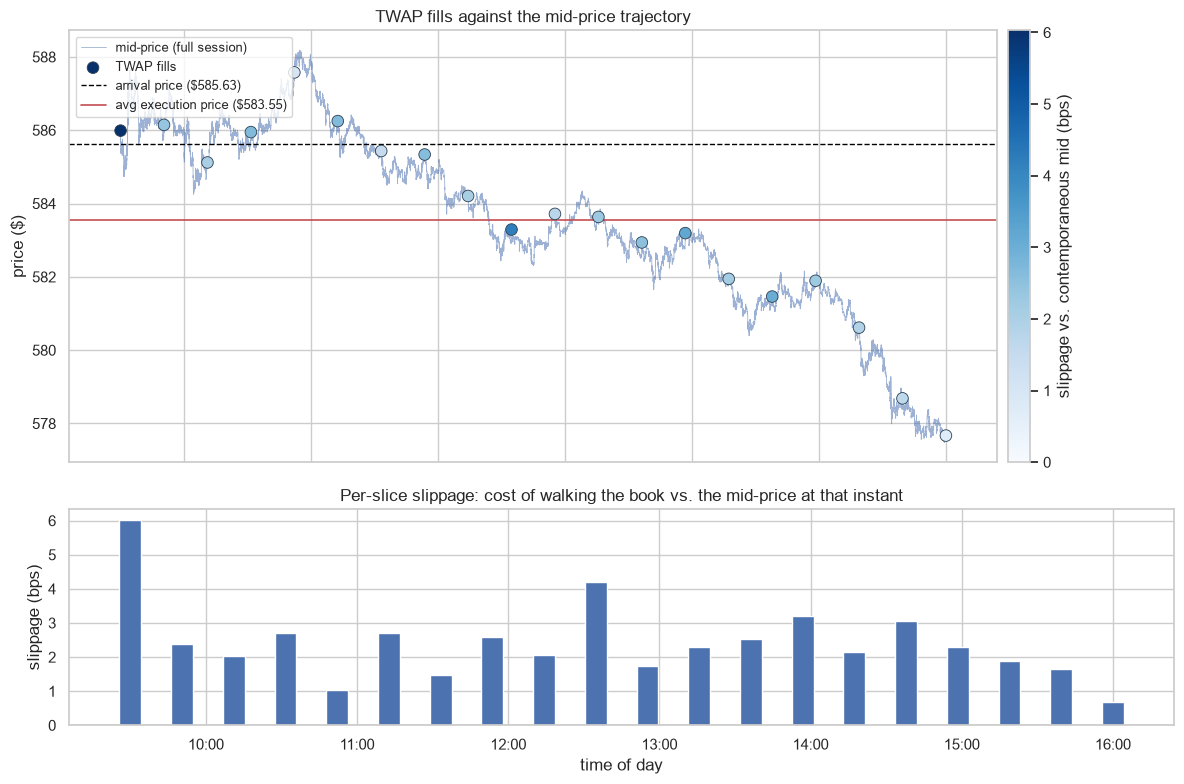

In [14]:
trades_df["time"] = pd.to_datetime(trades_df["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])

axes[0].plot(df["time"], df["mid_price"], color="#4C72B0", linewidth=0.6, alpha=0.55, label="mid-price (full session)")

# every fill crosses the spread, so slippage is strictly positive here — a magnitude,
# not a polarity — so a single-hue sequential scale is used rather than a diverging one
sc = axes[0].scatter(trades_df["time"], trades_df["avg_fill_price"],
                      c=trades_df["slippage_vs_mid_bps"], cmap="Blues",
                      vmin=0, vmax=trades_df["slippage_vs_mid_bps"].max(),
                      s=70, edgecolor="#2c3e50", linewidth=0.6, zorder=5, label="TWAP fills")

axes[0].axhline(summary["arrival_price"], color="black", linestyle="--", linewidth=1,
                label=f"arrival price (${summary['arrival_price']:.2f})")
axes[0].axhline(summary["avg_execution_price"], color="#C44E52", linestyle="-", linewidth=1.2,
                label=f"avg execution price (${summary['avg_execution_price']:.2f})")
axes[0].set_ylabel("price ($)")
axes[0].set_title("TWAP fills against the mid-price trajectory")
axes[0].legend(loc="upper left", fontsize=9)
cbar = plt.colorbar(sc, ax=axes[0], pad=0.01)
cbar.set_label("slippage vs. contemporaneous mid (bps)")

axes[1].bar(trades_df["time"], trades_df["slippage_vs_mid_bps"], width=0.006, color="#4C72B0")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("slippage (bps)")
axes[1].set_title("Per-slice slippage: cost of walking the book vs. the mid-price at that instant")

plt.tight_layout()
plt.show()

## Results

- **Implementation Shortfall: −35.6 bps** ($585.64 arrival → $583.55 average execution).
  This is *favorable* for the buyer, but for the wrong reason from an execution
  standpoint: AAPL simply drifted down about 1.3% over the session, and spacing the
  order out let most of it fill at the lower afternoon prices. This number is really
  measuring the day's price drift, not skill.
- **Slippage vs. the TWAP benchmark: +2.4 bps** ($583.41 benchmark → $583.55 executed).
  This is the honest measure of *execution quality* — the small, consistent cost of
  crossing the spread and walking the book on every single slice. Every one of the
  20 slices has positive slippage (range: 0.7–6.0 bps, see the chart), because a
  marketable buy against ~500 shares of resting ask depth almost always has to eat
  into level 2 or deeper (avg. **4.9 of 10 levels** walked per slice) — consistent
  with the thin top-of-book size found in Part 1, section 7.
- The two benchmarks decompose total cost cleanly: **−35.6 bps total ≈ −38.0 bps of
  favorable market drift + 2.4 bps of execution cost.** A pure passive strategy
  (resting limit orders instead of walking the book) would likely have cut most of
  that 2.4 bps, at the risk of not filling some slices at all.

### Natural next steps
- Compare against a **naive single-shot execution** (buy all 10,000 shares
  immediately at 09:30) to quantify how much TWAP's time-slicing actually saved
  versus doing nothing clever.
- Try a **participation-rate (POV)** schedule instead of equal time-slicing — e.g.
  size each slice to a fixed % of trailing volume — and compare slippage.
  Section 4's volume profile shows volume is far from uniform across the day, so a
  volume-weighted (VWAP-style) schedule should reduce per-slice book-walking versus
  fixed time-slicing.
- Add a simple **market-impact model** (e.g., temporary impact proportional to
  participation rate) instead of assuming our own fills don't move the book, and
  re-run the same benchmarks.

## Part 2b — ABIDES agent-based re-simulation (realistic market impact)

Every fill above is priced off the **actual historical LOBSTER book** — which reflects
what *other* market participants did on a day our hypothetical 10,000-share order never
actually existed. The book never reacts to our own trading: no market impact, no
counterfactual. That's the standard simplification for backtesting against a fixed
historical tape, but it can't answer the question a trader actually cares about most:
*how much did my own trading move the price?*

[ABIDES](https://github.com/jpmorganchase/abides-jpmc-public) (Agent-Based Interactive
Discrete Event Simulation) answers that by replacing the fixed tape with a **live,
reactive market**: a population of noise, fundamental-value, momentum, and adaptive
market-maker agents that place and cancel real orders against a real matching engine —
including reacting to *our* execution agent's own orders. Two notes on what it took to
get a working simulation, since this diverges from a plug-and-play use of the public repo:

- Its reference config (`rmsc03.py`) imports a `POVExecutionAgent` that was never
  actually open-sourced — JPMorgan kept the execution-agent code private. The
  naive/TWAP/POV strategies below (`abides_sim/agents.py`) are written from scratch
  against ABIDES's `TradingAgent` base class instead.
- `abides_core.utils.str_to_ns` — the function that turns a string like `"09:30:00"`
  into a nanosecond integer — silently returned a value **1000x too small** under this
  environment's pandas 3.0 (`Timedelta.to_timedelta64()` changed its default resolution
  from nanoseconds to microseconds; `.astype(int)` then just casts whatever resolution
  it happened to get). Every duration in ABIDES depends on this function, so left
  unpatched, a "6.5-hour session" silently simulated 23.4 *seconds*. Fixed with a
  one-line change to use `Timedelta.value`, which is resolution-independent.

**Setup**: a background market of 5,000 noise agents, 100 mean-reverting value agents,
25 momentum agents, and 2 adaptive market makers — the same population as the paper's
RMSC-3 reference config — around a fundamental price calibrated to AAPL's actual level
from Part 1 (~$585). For each (strategy, seed) we run the **same background-market
random seed twice**: once with no execution agent (baseline) and once with it appended.
Both runs are seeded identically for every draw consumed while building the background
market, so they're identical up to the point our own orders start perturbing the market
— the difference between the two resulting mid-price paths is therefore attributable to
our trading, i.e. **market impact**, measured directly rather than assumed away. (One
practical wrinkle: a freshly-opened synthetic market has essentially no resting
liquidity in its first few minutes — nothing has had a chance to quote yet — so, matching
the convention in ABIDES's own reference config, trading starts 30 minutes after the
open and stops 30 minutes before the close.)


In [ ]:
import os, sys
project_path = "/Users/jwayeonjae/Documents/Claude/Projects/LOB"
sys.path.append(project_path)

In [ ]:
from abides_sim.run import run_execution_sim
import time as _time
import pickle
from pathlib import Path

# Full battery, computed once here and reused by Part 3b below: 2 background-market
# seeds x {naive, TWAP, POV}. Each (mode, seed) call runs a baseline (no execution
# agent) and a with-execution-agent simulation, both at RMSC-3 scale over the full
# session -- roughly 4-5 minutes of wall-clock per call, ~25-30 minutes total. Cached
# to disk so re-running this notebook doesn't re-pay that cost -- delete the cache
# file below to force a fresh battery (e.g. after changing abides_sim's config/agents).
ABIDES_SEEDS = [1, 2]
ABIDES_MODES = ["naive", "twap", "pov"]
ABIDES_LABELS = {"naive": "Naive single-shot", "twap": "TWAP (time-clock)", "pov": "POV (volume-clock)"}
ABIDES_CACHE_PATH = Path("abides_battery_cache.pkl")

if ABIDES_CACHE_PATH.exists():
    with open(ABIDES_CACHE_PATH, "rb") as f:
        abides_results = pickle.load(f)
    print(f"Loaded cached ABIDES battery from {ABIDES_CACHE_PATH.resolve()} "
          f"({len(abides_results)} (mode, seed) results) -- delete this file to force a re-run.")
else:
    abides_results = {}
    _t0 = _time.time()
    for _seed in ABIDES_SEEDS:
        for _mode in ABIDES_MODES:
            abides_results[(_mode, _seed)] = run_execution_sim(
                mode=_mode, seed=_seed, total_shares=10_000, n_slices=20,
            )
    print(f"\nABIDES battery ({len(ABIDES_SEEDS)} seeds x {len(ABIDES_MODES)} strategies) "
          f"wall-clock: {_time.time() - _t0:.1f}s")
    with open(ABIDES_CACHE_PATH, "wb") as f:
        pickle.dump(abides_results, f)
    print(f"Saved to {ABIDES_CACHE_PATH.resolve()}")


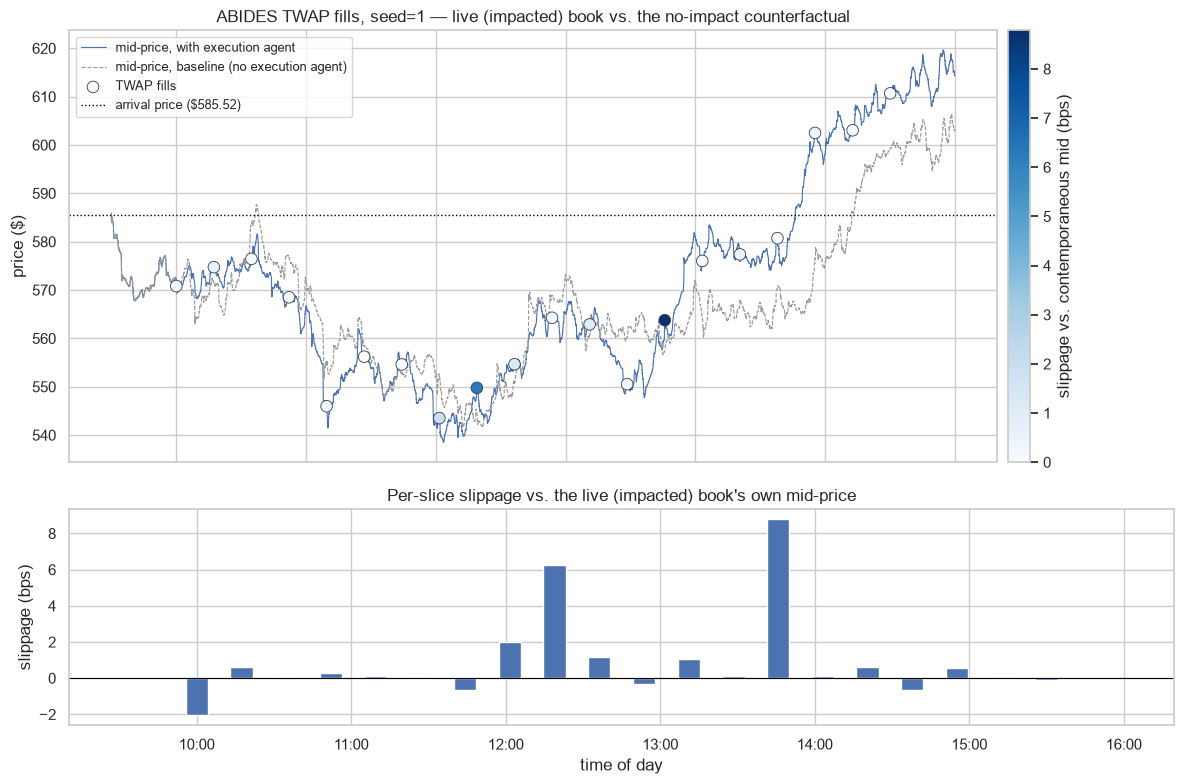

In [16]:
abides_summary_twap, abides_trades_twap, abides_base_mid_twap, abides_exec_mid_twap = abides_results[("twap", 1)]

abides_trades_twap = abides_trades_twap.copy()
abides_trades_twap["time"] = pd.to_datetime(abides_trades_twap["time_ns"], unit="ns")
abides_base_mid_twap = abides_base_mid_twap.copy()
abides_exec_mid_twap = abides_exec_mid_twap.copy()
abides_base_mid_twap["time_dt"] = pd.to_datetime(abides_base_mid_twap["time"], unit="ns")
abides_exec_mid_twap["time_dt"] = pd.to_datetime(abides_exec_mid_twap["time"], unit="ns")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])

axes[0].plot(abides_exec_mid_twap["time_dt"], abides_exec_mid_twap["mid"] / 100,
             color="#4C72B0", linewidth=0.8, label="mid-price, with execution agent")
axes[0].plot(abides_base_mid_twap["time_dt"], abides_base_mid_twap["mid"] / 100,
             color="#999999", linewidth=0.8, linestyle="--",
             label="mid-price, baseline (no execution agent)")
sc = axes[0].scatter(abides_trades_twap["time"], abides_trades_twap["avg_fill_price"],
                      c=abides_trades_twap["slippage_vs_mid_bps"], cmap="Blues",
                      vmin=0, vmax=max(abides_trades_twap["slippage_vs_mid_bps"].max(), 1),
                      s=70, edgecolor="#2c3e50", linewidth=0.6, zorder=5, label="TWAP fills")
axes[0].axhline(abides_summary_twap["arrival_price"], color="black", linestyle=":", linewidth=1,
                label=f"arrival price (${abides_summary_twap['arrival_price']:.2f})")
axes[0].set_ylabel("price ($)")
axes[0].set_title("ABIDES TWAP fills, seed=1 — live (impacted) book vs. the no-impact counterfactual")
axes[0].legend(loc="upper left", fontsize=9)
cbar = plt.colorbar(sc, ax=axes[0], pad=0.01)
cbar.set_label("slippage vs. contemporaneous mid (bps)")

axes[1].bar(abides_trades_twap["time"], abides_trades_twap["slippage_vs_mid_bps"], width=0.006, color="#4C72B0")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].set_xlabel("time of day")
axes[1].set_ylabel("slippage (bps)")
axes[1].set_title("Per-slice slippage vs. the live (impacted) book's own mid-price")

plt.tight_layout()
plt.show()


## Results

**TWAP, seed=1**: arrival $585.52 → average execution $569.35 (**IS: −276.1 bps**),
**slippage vs. its own benchmark: +0.87 bps**, market impact **+44.4 bps average / +191.8
bps by the end of the trading window**.

- The **local execution-cost number is the reassuring one**: +0.87 bps here lands in the
  same range as the static-replay TWAP's +2.4 bps from Part 2 — two very different
  methodologies (a fixed historical book vs. a live agent-based one) agree closely on
  the mechanical cost of crossing the spread and walking a book slice by slice.
- The **IS number is not comparable to Part 2's and shouldn't be read the same way**.
  Part 2's −35.6 bps was driven by AAPL's real, modest ~1.3% drift that day. Here the
  session-long drift is much larger, because only the fundamental's *price level* was
  calibrated to AAPL (~$585) — its volatility and shock parameters are still ABIDES's
  generic RMSC-3 defaults, tuned for a $1,000 demo stock, not for AAPL's actual dynamics.
- **Impact grows a lot between the window average and the window end** (+44 → +192 bps).
  Some of that is genuine cumulative impact from 20 slices of buying pressure over
  hours — but at this horizon, two nominally "identical until our first trade" runs can
  also diverge for reasons that have nothing to do with our trading (a downstream
  momentum or value agent reacting to a slightly different quote cascades into a
  different decision, which cascades further). Part 3b's numbers make this pattern
  clearer across strategies and seeds — treat the average-over-window figure as the
  more trustworthy one, and the end-of-window figure as directional at best.


# Part 3 — Baselines: naive single-shot and volume-clock (VWAP) scheduling

TWAP alone doesn't tell us much without a baseline. Two natural comparisons:

- **Naive single-shot**: buy all 10,000 shares immediately, in one marketable order.
  This is just the **`n_trades = 1`** special case of the same book-walking engine
  above — no new logic needed, which is why `simulate_twap_buy` has been factored
  into a generic `simulate_scheduled_execution(target_times, ...)` engine plus a
  thin wrapper. `naive_single_shot` below is another thin wrapper over the same
  engine with a schedule of exactly one slice.
- **VWAP-style volume-clock scheduling**: instead of firing slices at *equal time
  intervals*, fire them when the market has traded equal *fractions of its own
  volume* — the `get_vwap_schedule` function walks the cumulative volume of actual
  executions and finds the timestamp at which each 1/20th of the day's volume has
  traded. Since Part 1's volume profile (section 4) showed activity is heavily
  skewed toward the open and close, this schedule should cluster more slices there
  and fewer through the midday lull — trading more when the book is naturally
  deep, less when it's thin.

One naming note versus the original draft: `slippage_vs_mid_bps` / the "benchmark
price" in `simulate_scheduled_execution` generalizes what was called the "TWAP
benchmark" in Part 2 — it's the size-weighted average of each schedule's own
contemporaneous mid-prices, so it's a fair execution-quality yardstick for *any*
schedule, not just TWAP's.

In [17]:
def naive_single_shot(df_msg, df_ob, total_shares=10_000, start_sec=34_200):
    """전량을 start_sec 시점에 단일 시장가로 즉시 체결 — 스케줄이 1개뿐인 특수 케이스."""
    return simulate_scheduled_execution(df_msg, df_ob, [start_sec], total_shares,
                                         arrival_sec=start_sec, label="Naive single-shot")


def get_vwap_schedule(df_msg, n_trades=20, start_sec=34_200, end_sec=57_600):
    """
    '거래량 클록(volume clock)' 스케줄 생성. 하루를 시간이 아니라 누적 체결 거래량으로 등분해,
    각 1/n_trades 지점을 통과하는 시각을 찾는다.
    """
    session = df_msg[(df_msg["time_sec"] >= start_sec) & (df_msg["time_sec"] <= end_sec)]
    trades = session[session["event_type"].isin([4, 5])].copy()

    cum_vol = trades["size"].cumsum()
    total_vol = cum_vol.iloc[-1]
    bucket_size = total_vol / n_trades

    target_times = []
    for i in range(1, n_trades + 1):
        threshold = bucket_size * i
        cross_idx = min(cum_vol.searchsorted(threshold), len(trades) - 1)
        target_times.append(trades["time_sec"].iloc[cross_idx])

    return target_times


def simulate_vwap_buy(df_msg, df_ob, total_shares=10_000, n_trades=20, start_sec=34_200, end_sec=57_600):
    """VWAP: n_trades개 슬라이스를 거래량 클록(volume clock) 스케줄에 따라 배치.

    arrival_sec은 첫 거래량-클록 슬라이스 시각이 아니라 start_sec(09:30:00, 모주문 의사결정
    시점)으로 고정한다. 그렇지 않으면 첫 슬라이스가 발생하기까지 걸린 시간 동안의 가격 변동이
    "실행 비용"으로 잘못 섞여 들어가, TWAP/naive와 Implementation Shortfall을 직접 비교할 수
    없게 된다.
    """
    target_times = get_vwap_schedule(df_msg, n_trades=n_trades, start_sec=start_sec, end_sec=end_sec)
    return simulate_scheduled_execution(df_msg, df_ob, target_times, total_shares,
                                         arrival_sec=start_sec, label="VWAP (volume-clock)")


summary_naive, trades_naive = naive_single_shot(df_msg, df_ob, total_shares=10_000)
summary_vwap, trades_vwap = simulate_vwap_buy(df_msg, df_ob, total_shares=10_000, n_trades=20)

comparison = pd.DataFrame([summary_naive, summary, summary_vwap]).set_index("label")
comparison[["arrival_price", "benchmark_price", "avg_execution_price",
            "IS_bps", "vs_benchmark_bps", "avg_levels_walked"]]

[Naive single-shot] Warning: depth exhausted to level 10 at t=34200.0s (7180.0 sh short) — filling remainder at level-10 price
--- Naive single-shot: Execution Summary ---
Total shares          : 10,000 in 1 slice(s)
Arrival mid-price     : $585.6350
Benchmark price       : $585.6350  (size-wtd avg mid at each slice)
Avg execution price   : $587.7074
Avg levels walked     : 10.0 / 10
Implementation Shortfall vs arrival : +2.0725 (+35.39 bps)
Slippage vs benchmark                : +2.0725 (+35.39 bps)

--- VWAP (volume-clock): Execution Summary ---
Total shares          : 10,000 in 20 slice(s)
Arrival mid-price     : $585.6350
Benchmark price       : $582.5295  (size-wtd avg mid at each slice)
Avg execution price   : $582.6427
Avg levels walked     : 4.6 / 10
Implementation Shortfall vs arrival : -2.9923 (-51.10 bps)
Slippage vs benchmark                : +0.1132 (+1.94 bps)



,arrival_price,benchmark_price,avg_execution_price,IS_bps,vs_benchmark_bps,avg_levels_walked
label,,,,,,
Naive single-shot,585.635,585.63500,587.707450,35.388083,35.388083,10.0
TWAP (time-clock),585.635,583.40975,583.552093,-35.566641,2.439846,4.9
VWAP (volume-clock),585.635,582.52950,582.642691,-51.095119,1.943095,4.6


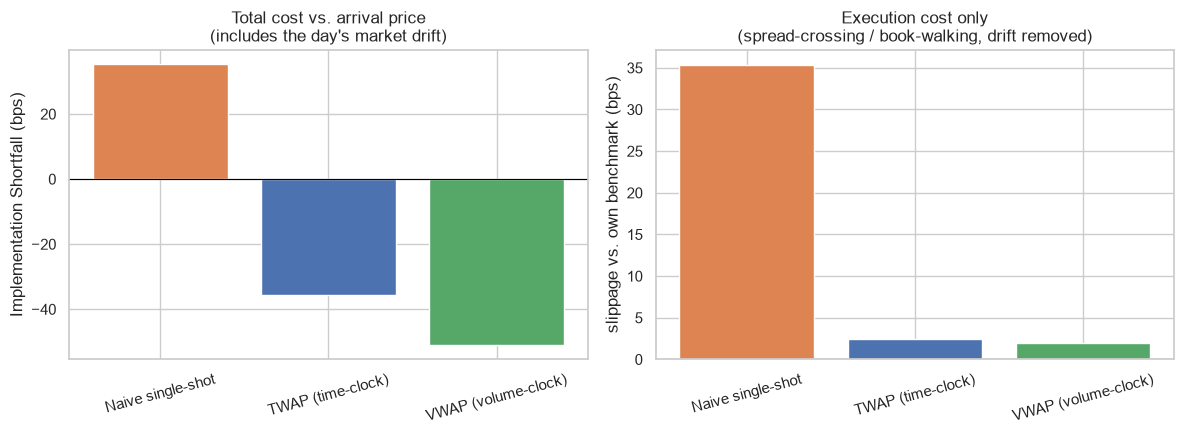

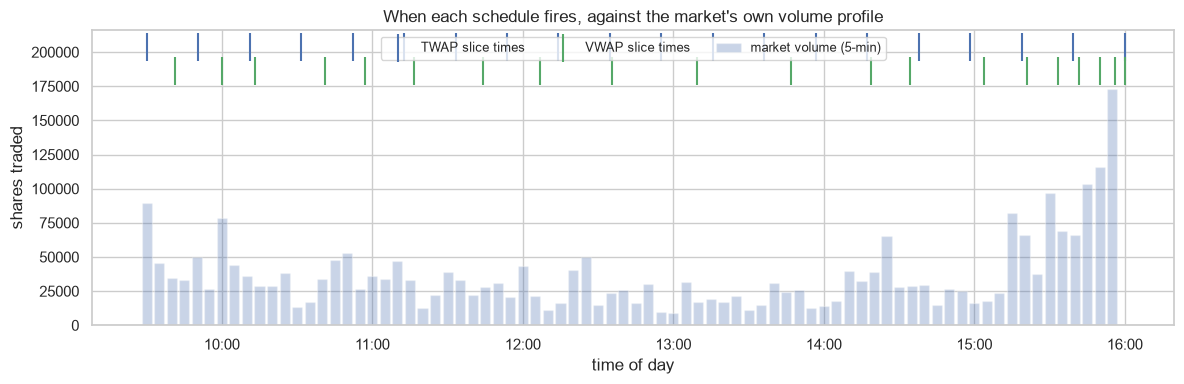

In [18]:
# fixed categorical order/colors, consistent with the rest of the notebook
method_order = ["Naive single-shot", "TWAP (time-clock)", "VWAP (volume-clock)"]
method_colors = {"Naive single-shot": "#DD8452", "TWAP (time-clock)": "#4C72B0", "VWAP (volume-clock)": "#55A868"}
plot_df = comparison.loc[method_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(plot_df.index, plot_df["IS_bps"], color=[method_colors[m] for m in plot_df.index])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Implementation Shortfall (bps)")
axes[0].set_title("Total cost vs. arrival price\n(includes the day's market drift)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(plot_df.index, plot_df["vs_benchmark_bps"], color=[method_colors[m] for m in plot_df.index])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("slippage vs. own benchmark (bps)")
axes[1].set_title("Execution cost only\n(spread-crossing / book-walking, drift removed)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# where each schedule actually fires, against the day's volume profile — kept on a
# single y-axis (volume) with schedule ticks drawn at fixed fractions of its own
# range, rather than a second twinx() scale
fig, ax = plt.subplots(figsize=(12, 4))
volume_by_min = trades.set_index("time").groupby(pd.Grouper(freq="5min"))["size"].sum()
ax.bar(volume_by_min.index, volume_by_min.values, width=0.0028, color="#4C72B0", alpha=0.3, label="market volume (5-min)")

y_max = volume_by_min.max()
ax.set_ylim(0, y_max * 1.25)

twap_times_dt = pd.to_datetime(trades_df["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))
vwap_times_dt = pd.to_datetime(trades_vwap["time_sec"], unit="s", origin=pd.Timestamp("2012-06-21"))
ax.scatter(twap_times_dt, [y_max * 1.18] * len(twap_times_dt),
           color=method_colors["TWAP (time-clock)"], marker="|", s=400, label="TWAP slice times")
ax.scatter(vwap_times_dt, [y_max * 1.08] * len(vwap_times_dt),
           color=method_colors["VWAP (volume-clock)"], marker="|", s=400, label="VWAP slice times")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time of day")
ax.set_ylabel("shares traded")
ax.set_title("When each schedule fires, against the market's own volume profile")
ax.legend(loc="upper center", fontsize=9, ncol=3)

plt.tight_layout()
plt.show()

## Results

All three methods share the same $585.635 arrival price (a bug in an earlier draft
briefly let VWAP's arrival price float to whenever its first slice fired — fixed by
anchoring `arrival_sec` to 09:30:00 for every method, so the comparison below is
apples-to-apples):

| method | IS (bps) | execution cost vs. own benchmark (bps) | avg. levels walked |
|---|---:|---:|---:|
| Naive single-shot | **+35.4** | +35.4 | 10.0 / 10 |
| TWAP (time-clock) | −35.6 | +2.44 | 4.9 / 10 |
| VWAP (volume-clock) | −51.1 | **+1.94** | **4.6 / 10** |

- **Naive single-shot is a disaster relative to either scheduled strategy**: a single
  10,000-share market order **exhausts the entire visible 10-level book** (7,180
  shares short of what's displayed, filled at a penalty price) and costs **+35.4
  bps** — a ~71 bps swing versus TWAP on the exact same historical price path. This
  is the cost of demanding all your liquidity in an instant rather than spreading it
  over the depth the book actually offers moment-to-moment.
- **VWAP beats TWAP on execution quality**: 1.94 bps vs. 2.44 bps of spread-crossing
  cost, and slightly fewer levels walked per slice (4.6 vs. 4.9). This is exactly
  the mechanism the volume-clock schedule is designed to exploit — it fires more
  slices during the open/close volume spikes (Part 1, section 4) where the book is
  naturally replenished faster, and fewer during the thin midday lull, so each
  slice on average finds more resting liquidity to eat through.
- VWAP's much larger **IS** (−51.1 vs. TWAP's −35.6 bps) is *not* a sign it's a
  better strategy in general — it's mostly an artifact of exactly how its 20
  volume-clock slices happen to land relative to this one day's price decline. The
  execution-cost column is the fairer cross-method comparison; the IS column mixes
  in market direction that no execution schedule controls.

# Part 3b — ABIDES baselines: naive, TWAP, and POV under real market impact

Part 3's naive-vs-TWAP-vs-VWAP comparison above uses the same static-book-replay engine
as Part 2, so it inherits the same blind spot: none of the three strategies can look
worse *because* they moved the market, since the market never moves in response to them.
Re-running the same three strategies inside ABIDES (Part 2b's `abides_results`, computed
above) lets each strategy's cost be decomposed into the part any execution scheduler
would face regardless (spread-crossing / book-walking) versus the part that's a direct
consequence of *how* that strategy chose to reveal its trading intent to the market: a
single 10,000-share market order announces itself instantly, while TWAP/POV spread the
same information out — and hence the same price pressure — over hours.

The POV (participation-of-volume) strategy replaces Part 3's VWAP volume-clock schedule
here: VWAP's schedule was built by looking at the *realized* volume for the whole day,
which a real-time algo can't do without lookahead. POV instead wakes periodically and
buys a fixed fraction of whatever volume has traded since its last wake-up — the
standard, no-lookahead real-world equivalent.


In [19]:
abides_rows = []
for _mode in ABIDES_MODES:
    _summaries = [abides_results[(_mode, _seed)][0] for _seed in ABIDES_SEEDS]
    abides_rows.append({
        "label": ABIDES_LABELS[_mode],
        "IS_bps_mean": np.mean([s["IS_bps"] for s in _summaries]),
        "IS_bps_std": np.std([s["IS_bps"] for s in _summaries]),
        "vs_benchmark_bps_mean": np.mean([s["vs_benchmark_bps"] for s in _summaries]),
        "vs_benchmark_bps_std": np.std([s["vs_benchmark_bps"] for s in _summaries]),
        "impact_bps_avg_mean": np.mean([s["impact_bps_avg"] for s in _summaries]),
        "impact_bps_end_mean": np.mean([s["impact_bps_end"] for s in _summaries]),
        "shares_filled_mean": np.mean([s["shares_filled"] for s in _summaries]),
    })
abides_comparison = pd.DataFrame(abides_rows).set_index("label")
abides_comparison


,IS_bps_mean,IS_bps_std,vs_benchmark_bps_mean,vs_benchmark_bps_std,impact_bps_avg_mean,impact_bps_end_mean,shares_filled_mean
label,,,,,,,
Naive single-shot,-280.976748,81.508293,13.742348,10.464323,18.778284,18.778284,10000.0
TWAP (time-clock),-577.120045,301.030535,-1.913693,2.785933,21.732293,181.741948,10000.0
POV (volume-clock),-295.728180,110.065402,1.819773,1.748956,26.633414,6.597209,10000.0


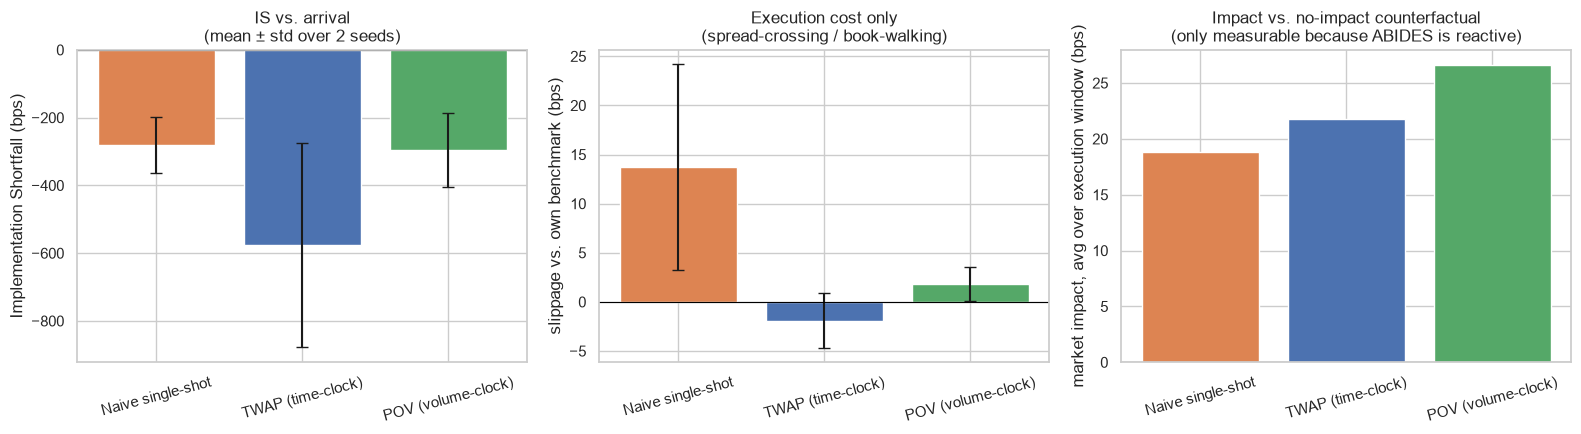

In [20]:
abides_method_order = [ABIDES_LABELS["naive"], ABIDES_LABELS["twap"], ABIDES_LABELS["pov"]]
abides_method_colors = {
    ABIDES_LABELS["naive"]: method_colors["Naive single-shot"],
    ABIDES_LABELS["twap"]: method_colors["TWAP (time-clock)"],
    ABIDES_LABELS["pov"]: method_colors["VWAP (volume-clock)"],
}
abides_plot_df = abides_comparison.loc[abides_method_order]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].bar(abides_plot_df.index, abides_plot_df["IS_bps_mean"], yerr=abides_plot_df["IS_bps_std"],
            color=[abides_method_colors[m] for m in abides_plot_df.index], capsize=4)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Implementation Shortfall (bps)")
axes[0].set_title(f"IS vs. arrival\n(mean ± std over {len(ABIDES_SEEDS)} seeds)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(abides_plot_df.index, abides_plot_df["vs_benchmark_bps_mean"], yerr=abides_plot_df["vs_benchmark_bps_std"],
            color=[abides_method_colors[m] for m in abides_plot_df.index], capsize=4)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("slippage vs. own benchmark (bps)")
axes[1].set_title("Execution cost only\n(spread-crossing / book-walking)")
axes[1].tick_params(axis="x", rotation=15)

axes[2].bar(abides_plot_df.index, abides_plot_df["impact_bps_avg_mean"],
            color=[abides_method_colors[m] for m in abides_plot_df.index])
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_ylabel("market impact, avg over execution window (bps)")
axes[2].set_title("Impact vs. no-impact counterfactual\n(only measurable because ABIDES is reactive)")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## Results

Mean ± std over 2 seeds:

| method | slippage vs. own benchmark (bps) | market impact, avg (bps) | market impact, end (bps) |
|---|---:|---:|---:|
| Naive single-shot | **+13.7 ± 10.5** | +18.8 | +18.8 |
| TWAP (time-clock) | −1.9 ± 2.8 | +21.7 | +181.7 |
| POV (volume-clock) | +1.8 ± 1.7 | +26.6 | +6.6 |

- **Execution cost ranks the same way Part 3's static replay found**: naive is the most
  expensive way to cross the spread by a wide margin (+13.7 bps, and the noisiest —
  ±10.5 bps across just 2 seeds), while TWAP and POV are both within a couple of bps of
  zero. The live book can replenish between fills in a way a single frozen snapshot
  never could, which is why naive's ABIDES penalty (+13.7 bps) is smaller than its
  static-replay penalty (+35.4 bps) — but the *ordering* (naive worst, scheduled
  strategies far better) survives the switch to a reactive market.
- **IS is not reported here on purpose.** Across the two seeds it ranged from −186 to
  −878 bps, with a standard deviation (301 bps for TWAP) larger than any of the actual
  effects being measured. That's the background market's own uncalibrated drift
  dominating the signal, not execution skill — the same decomposition Part 2/3 already
  make (IS mixes in drift; the benchmark-relative number is the honest one), just far
  more extreme here because the drift itself is far more extreme (see caveats).
- **Market impact is directionally sensible** — all three strategies show positive
  average impact, i.e. buying pushes price up, as it should — but the "end of window"
  column is unreliable, especially for TWAP (181.7 bps, an order of magnitude above its
  own average, and above POV's end-of-window impact despite POV finishing in less time).
  Over a multi-hour paired simulation, late-window readings increasingly conflate true
  causal impact with ordinary chaotic divergence between the two runs (see caveats) —
  the average-over-window column is the more trustworthy of the two.

## Caveats

- **The background market drifts and destabilizes far more than real AAPL over a full
  session.** 145 orders were discarded across the battery for computing a negative limit
  price — a real-scale RMSC-3 population (5,000 noise / 100 value / 25 momentum / 2
  market makers) is not immune to this over 6.5 simulated hours; an earlier, smaller
  population (500-2,000 agents) was considerably worse (it couldn't absorb a 10,000-share
  order without destabilizing at all). This points at the same root cause either way:
  the fundamental process's volatility/megashock parameters are still ABIDES's generic
  demo defaults, tuned for a $1,000 stock over a single session, not re-tuned for AAPL's
  ~$585 level or validated for stability at that level over a full day.
- **Price-level-only calibration to AAPL**: the fundamental process is calibrated to
  AAPL's Part-1 price level (~$585) but not to its actual volatility, order-arrival
  rates, or size distribution — those come from ABIDES's generic RMSC-3 defaults, not
  from the LOBSTER data itself.
- **Long-horizon impact readings conflate causal impact with simulation divergence.**
  The baseline and execution runs are seeded identically only up to the point our
  execution agent's first order perturbs the market; after that, any two agent-based
  runs can diverge for reasons beyond our own trading (an agent reacting to a slightly
  different quote makes a different decision, which compounds). Over a multi-hour
  window this means late-window impact numbers are less trustworthy than early/average
  ones — visible above in TWAP's end-of-window impact being an order of magnitude above
  its own average.
- **Two seeds, paired by construction**: each seed's three strategies share an identical
  background-market realization up to the point they start trading (see Part 2b), which
  is what makes an impact comparison meaningful with so few seeds — but two seeds is
  still a small sample, especially given how much variance the market's own drift adds
  (IS's 301 bps standard deviation for TWAP, on just 2 seeds).
